# Bias-reduced sparse SGD against DP-SGD, on one-hot Criteo

The evaluation the port exists for. `bias_reduced_sgd` — Ghazi, Guzmán,
Kamath, Kumar and Manurangsi, *Differentially Private Optimization with
Sparse Gradients*, NeurIPS 2024
([arXiv:2404.10881](https://arxiv.org/abs/2404.10881)), Algorithms 3 and 4 —
claims a rate that depends on the sparsity of the gradients rather than on
the dimension. One-hot Criteo is the dataset where that assumption holds
exactly rather than approximately: `load_criteo_one_hot` (ADR-0020) encodes
all 39 columns at their native cardinalities into 551,947 coordinates and
returns the 39 indices each row occupies, so every per-sample gradient has
exactly 40 nonzero coordinates by construction — assumption (A.7), held and
not hoped for. If the method is going to beat DP-SGD anywhere, it is here.

Three arms, on the same rows, the same model and the same loss:

- **non-private SGD**, the unbounded-leakage end of the axis;
- **DP-SGD** (Abadi et al., 2016, [arXiv:1607.00133](https://arxiv.org/abs/1607.00133)),
  per-sample clipping and Gaussian noise on Poisson lots;
- **`bias_reduced_sgd`**, at the operating point the bias-reduced-SGD sweep
  froze.

This is the DP-SGD-vs-SGD-baseline comparison's shape — that notebook put
DP-SGD against non-private SGD on the dense 39-feature encoding at ε = 3 —
moved to the sparse encoding, brought down to the budget the new algorithm
admits, and given a third arm. None of the DP-SGD-vs-SGD-baseline comparison's
numbers are carried over: different encoding, different budget, different step
count, so every figure below is read off this execution.

**The headline is negative, and the bias-reduced-SGD sweep already said why.**
At ε = 1, the largest budget Lemma 5.3 covers, every inner release of
`bias_reduced_sgd` runs at a noise multiplier of 250, and the arm does not
leave its initialization. DP-SGD at the *same* budget does. What this notebook
adds to that sweep is the comparison that makes that a result rather than a
disappointment: the same data, the same ε, the same δ, the same
steps, and a private arm that works right beside the one that does not.

**The `bias_reduced_sgd` operating point is inherited, and it is a coin
toss.** The bias-reduced-SGD sweep swept all three of the algorithm's knobs
and found nine statistically indistinguishable configurations; the log-loss
rule named `max_scale = 10`, `C = 1.0`, `lr = 0.01`, and that row has the
*worst* PR-AUC of its own clip column. Section 6 repeats that where the arm is
reported. Nothing here re-tunes it: a comparison confirms an arm near a known
operating point, and the tuning happened in the DP-SGD sweep and the
bias-reduced-SGD sweep.

> ### The run this file carries
>
> **The outputs stored here are the full configuration**, `SMOKE = False`:
> 3,000 optimizer steps in every arm, 5 runs in the non-private grid, 16 in
> the DP-SGD grid, 4 run lengths for the frozen `bias_reduced_sgd` arm, a
> 20-point trajectory for each of the two arms that can be resumed and a
> four-point one for the third, one off-budget DP-SGD reference and a
> three-seed repeat of all three arms — 37 training runs, executed in one
> process on one RTX 6000 Ada. Both private arms are calibrated to
> **ε = 1, δ = 1e-12**; section 3 is where that pair is argued for.
>
> The configuration block carries a `SMOKE` switch, which shortens the step
> count, the grids, the trajectory and the seed list — and nothing else — so
> the whole path can be exercised cheaply after an edit. It is a development
> convenience; it is not what this file was run with.

In [1]:
import os

# The sweeps below run configurations concurrently on one device, and the
# pool is sized against what the allocator will hand out (section 4). JAX
# reads this once, at import, and takes 75% of the device without it.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.8")

import math
import time
from concurrent.futures import ThreadPoolExecutor
from typing import Any, Callable, NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import dimma
from dimma.accounting import bias_reduced_sgd as brs_accounting
from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.bias_reduced_sgd import train as bias_reduced_sgd
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.algorithms.sgd import train as sgd
from dimma.core import gradients, updates
from dimma.core.sampling import dyadic, poisson
from dimma.datasets.criteo import load_criteo_one_hot
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
)
from dimma.metrics.decomposition import log_loss_decomposition
from dimma.metrics.operating_point import Confusion, best_f1_threshold, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward_sparse, init_params

print("dimma:", dimma.__file__)
DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# Three arms, three hues, in the DP-SGD-vs-SGD-baseline comparison's and
# the bias-reduced-SGD sweep's assignment: blue is the non-private baseline,
# orange the DP-SGD arm, green the bias-reduced one.
# The set clears the colour-vision and normal-vision separation floors on
# every pair; green sits under 3:1 against the surface, so every point it
# draws is also printed in a table beside the figure.
INK, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e1e0d9"
SERIES = {"plain SGD": "#2a78d6", "DP-SGD": "#eb6834",
          "bias_reduced_sgd": "#1baf7a"}
# A second channel on every figure that draws all three, so identity is
# never carried by colour alone.
MARKERS = {"plain SGD": "o", "DP-SGD": "s", "bias_reduced_sgd": "^"}
ARMS = tuple(SERIES)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 7.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})

dimma: /home/diegol/dimma_lib/.claude/worktrees/agent-afe3fe4a94db3b813/src/dimma/__init__.py


jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


### The configuration block

One block. `SMOKE` moves the step count, the two grids, the run-length grid,
the trajectory resolution and the seed list; **everything else — the budget,
the frozen `bias_reduced_sgd` point, the bin count, the threshold rule, the
selection rule, the metrics — is the protocol and does not move.**

The `bias_reduced_sgd` constants are not tuning parameters of this notebook.
They are the bias-reduced-SGD sweep's output, transcribed: `max_scale = 10`,
`C = 1.0`, `radius = C·√40`, `lr = 0.01`, the default `projection_estimator`,
and `average_params` as the reported iterate.

In [2]:
SMOKE = False

# ---- the protocol. Identical across the arms. ---------------------------
TARGET_EPSILON = 1.0     # the ceiling bias_reduced_sgd refuses to exceed
TARGET_DELTA = 1e-12     # below 1 / n ** 2; section 3 argues for both
ACCOUNTANT = "rdp"       # ADR-0011, held fixed across the two private arms
N_BINS = 15              # equal-mass bins, as everywhere in notebooks/
BATCH = 1024             # exact for plain SGD, expected for DP-SGD's lots
INIT_SEED = 0            # the one initialization, every run, every arm
BASE_SEED = 20260823     # the sampling and noise streams move off this
SPARSITY = 40            # 39 stored features and the bias, exactly (ADR-0020)
HOLDOUT = 100_000        # validation rows cut off the training split

# ---- the frozen point: the bias-reduced-SGD sweep's, not this file's. ---
BRS_MAX_SCALE = 10
BRS_CLIP_NORM = 1.0
BRS_RADIUS = BRS_CLIP_NORM * math.sqrt(SPARSITY)
BRS_LEARNING_RATE = 0.01

# ---- what SMOKE moves, and all it moves. --------------------------------
if SMOKE:
    STEPS = 200
    SGD_LR_GRID = (0.1, 1.0)
    DP_LR_GRID = (1.0,)
    DP_CLIP_GRID = (1.0,)
    BRS_STEP_GRID = (50, 200)
    TRAJECTORY_CHUNKS = 4
    SEEDS = (0, 1)
else:
    STEPS = 3_000
    SGD_LR_GRID = (0.03, 0.1, 0.3, 1.0, 3.0)
    DP_LR_GRID = (0.1, 0.3, 1.0, 3.0)
    DP_CLIP_GRID = (0.3, 1.0, 3.0, 10.0)
    BRS_STEP_GRID = (200, 600, 1_200, 3_000)
    TRAJECTORY_CHUNKS = 20
    SEEDS = (0, 1, 2)

assert BRS_STEP_GRID[-1] == STEPS, "the longest brs run is the reported one"
assert STEPS % TRAJECTORY_CHUNKS == 0

print(f"SMOKE = {SMOKE}")
print(f"  steps per run          : {STEPS:,} in every arm")
print(f"  plain SGD grid         : {len(SGD_LR_GRID)} runs")
print(f"  DP-SGD grid            : {len(DP_LR_GRID) * len(DP_CLIP_GRID)} runs")
print(f"  bias_reduced_sgd       : frozen by its own sweep, "
      f"{len(BRS_STEP_GRID)} run lengths")
print(f"  seed repeats           : {len(SEEDS)} per arm")

SMOKE = False
  steps per run          : 3,000 in every arm
  plain SGD grid         : 5 runs
  DP-SGD grid            : 16 runs
  bias_reduced_sgd       : frozen by its own sweep, 4 run lengths
  seed repeats           : 3 per arm


## 1. The data, and the two splits

Criteo click-through data with all 39 features one-hot encoded at the
cardinalities the training split gives them. The return is a
`SparseTabularSplit`, not a matrix: 39 indices and 39 values a row over a
feature space 551,947 wide, whose dense form would be 2.2 TB.

**The held-out rows are the same rows every other Criteo notebook scored on.**
The train/test cut is deterministic given `seed` and `test_fraction` and is
made by the same code in every mode, which a test pins — so the 200,000 test
rows here are the 200,000 test rows of the DP-SGD sweep, the
DP-SGD-vs-SGD-baseline comparison and the SpiderBoost-vs-DP-SGD comparison,
differently encoded. That is what makes it legitimate to read this notebook
beside those.

A second cut, this notebook's own, holds **100,000 of the 800,000 training
rows out for validation**, exactly as the DP-SGD-vs-SGD-baseline comparison
does: one permutation at a fixed seed, taken once and never re-drawn. Every
configuration below is selected on it, and the test split is not read until
section 8. That is a departure from the bias-reduced-SGD sweep, which trained
on all 800,000 rows and scored every configuration on the test split; it means
the `bias_reduced_sgd` arm here trains on 700,000 rows rather than 800,000,
and its numbers will not reproduce the sweep's to the digit.
The precondition that motivated the δ survives the change — `1 / 700,000 ** 2`
is 2.04e-12, still above δ = 1e-12 — and section 3 checks it rather than
asserting it.

`feature_norm_bound` is `None`. Unlike the SpiderBoost-vs-DP-SGD comparison,
no budget here reads it: DP-SGD's sensitivity is the clipping norm by
construction and `bias_reduced_sgd`'s is `2C` on a mean of clipped gradients,
so neither arm's ε is a function of the feature norms (contrast ADR-0012's
`R`, which *is* the budget for Private SpiderBoost). Capping rows would change
the data all three arms see and none of the guarantees they carry.

In [3]:
split = load_criteo_one_hot(preprocess=True, download=False, seed=INIT_SEED,
                            device=DEVICE, feature_norm_bound=None)

n_all, stored_per_row = split.idx_train.shape
n_features = split.num_features

# One deterministic cut of the training split. Not a resample: a permutation
# with a fixed seed, held out once and never re-drawn.
holdout = np.random.default_rng(BASE_SEED).permutation(n_all)
val_index = jnp.asarray(holdout[:HOLDOUT])
train_index = jnp.asarray(holdout[HOLDOUT:])

IDX_TRAIN, VAL_TRAIN = split.idx_train[train_index], split.val_train[train_index]
IDX_VAL, VAL_VAL = split.idx_train[val_index], split.val_train[val_index]
IDX_TEST, VAL_TEST = split.idx_test, split.val_test
Y_TRAIN = split.y_train[train_index]
Y_VAL_ARRAY = split.y_train[val_index]
Y_VAL = np.asarray(Y_VAL_ARRAY, dtype=np.float64)
Y_TEST = np.asarray(split.y_test, dtype=np.float64)

n_train = IDX_TRAIN.shape[0]
base_rate = float(Y_TEST.mean())
VAL_BASE_RATE = float(Y_VAL.mean())
THRESHOLD = float(Y_TRAIN.mean())

print(f"train {IDX_TRAIN.shape}   validation {IDX_VAL.shape}   "
      f"test {IDX_TEST.shape}")
print(f"{n_features:,} feature coordinates, {stored_per_row} stored a row")
print(f"label base rate: {THRESHOLD:.4f} train, "
      f"{VAL_BASE_RATE:.4f} validation, {base_rate:.4f} test")
print(f"PR-AUC floor (a random ranking scores the base rate): {base_rate:.4f}")
print(f"delta precondition: 1 / n ** 2 = {1 / n_train ** 2:.3e} against "
      f"delta = {TARGET_DELTA:.0e}  ->  "
      f"{'holds' if TARGET_DELTA < 1 / n_train ** 2 else 'FAILS'}")

criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point.


train (700000, 39)   validation (100000, 39)   test (200000, 39)
551,947 feature coordinates, 39 stored a row
label base rate: 0.2510 train, 0.2506 validation, 0.2520 test
PR-AUC floor (a random ranking scores the base rate): 0.2520
delta precondition: 1 / n ** 2 = 2.041e-12 against delta = 1e-12  ->  holds


A dimma per-sample loss is `(params, x_single, y_single) -> scalar` and every
`train` slices its `x` along one leading axis, so the two arrays a sparse row
comes in have to travel as one. They are concatenated: the first 39 columns
are the indices, the last 39 the values. Indices go through float32 exactly —
the widest is 551,946, well inside the 16,777,216 where float32 stops
counting by ones — and the assertion below is what says so rather than a
comment claiming it.

Both the packing and the loss are the bias-reduced-SGD sweep's, lifted
unchanged so the two notebooks run the same function on the same data. They
are notebook-local because `train` takes one `x`; a package seam for sparse
data would remove the duplication and is worth a ticket.

The loss is `per_sample_bce_loss` over `forward_sparse` rather than over
`forward`: the same model and the same logit, computed from the pair rather
than from the dense row it implies. It is written out here rather than
imported because the package's version composes with the dense forward, and
`softplus(z) - z*y` is the same overflow-safe rearrangement the package uses.
**All three arms are given this one function object**, which is what keeps
the comparison controlled.

In [4]:
X_TRAIN = jnp.concatenate(
    [IDX_TRAIN.astype(jnp.float32), VAL_TRAIN], axis=1
)
assert (np.asarray(X_TRAIN[:, :stored_per_row]).astype(np.int64)
        == np.asarray(IDX_TRAIN)).all(), "index round-trip is not exact"


def per_sample_sparse_bce(params, packed, y):
    """BCE for one example held as concatenated indices and values."""
    idx = packed[:stored_per_row].astype(jnp.int32)
    val = packed[stored_per_row:]
    logit = forward_sparse(params, idx, val)
    return jax.nn.softplus(logit) - logit * y


print(f"packed training features {X_TRAIN.shape} {X_TRAIN.dtype}, "
      f"{X_TRAIN.nbytes / 1e6:.0f} MB on {DEVICE}")

packed training features (700000, 78) float32, 218 MB on gpu


## 2. Shared machinery: one evaluator, one threshold, one set of numbers

Everything that could differ between the arms by accident is written once
here. All three start from the same parameters, `init_params(jax.random.key(0),
d)` — one starting point, not one per arm — descend with the same optimizer
object (ADR-0002), take the same number of steps, and are scored by the same
`evaluate_at`, which squashes the logits once and hands probabilities to
`dimma.metrics`. Nothing in this notebook computes a metric of its own.

**The five numbers** are the DP-SGD sweep's, the DP-SGD-vs-SGD-baseline
comparison's and the bias-reduced-SGD sweep's: log-loss, normalized entropy,
ECE at 15 equal-mass bins, the calibration ratio, and PR-AUC floored at the
base rate. **No ROC-AUC and no accuracy** (ADR-0016).

**The threshold is the bias-reduced-SGD sweep's, applied identically to all
three arms**: a record is flagged when the model puts it at or above the
**training-split base rate**. One number, fixed before any run, and a training
statistic rather than a further read of the test labels. The
DP-SGD-vs-SGD-baseline comparison used the validation-F1 cut instead, chosen
per model; that rule is reported as a secondary table in section 8, because a
reader arriving from the DP-SGD-vs-SGD-baseline comparison should be able to
see both and check that the ranking does not move with the cut.

In [5]:
_score = jax.jit(jax.vmap(forward_sparse, in_axes=(None, 0, 0)))


class Eval(NamedTuple):
    """Everything one parameter set is scored on, on one split."""

    loss: float
    ne: float
    ece: float
    cal_ratio: float
    pr_auc: float
    confusion: Confusion
    """Kept as the named value `confusion_at` returns: the four counts
    unpack in scikit-learn's ravelled order, which is the transposition
    its docstring warns about, so nothing here reads them by position."""
    probs: Any
    """The probabilities themselves, for the curves in section 8."""


class Fit(NamedTuple):
    """One trained arm, before it is scored."""

    params: Any
    """What the arm reports: `x-bar` for bias_reduced_sgd, the returned
    parameters for the other two."""
    alt_params: Any
    """`bias_reduced_sgd`'s last iterate, which no bound covers. `None`
    for the arms that return one parameter set."""
    steps: int
    epsilon: float
    """The accountant's number for the transcript that actually ran.
    `nan` for the non-private arm, which carries no epsilon at all."""


class SweepRow(NamedTuple):
    """One configuration in a grid, and what validation said about it.

    `clip_norm` is `None` in the non-private grid, which has no clipping
    line to sweep.
    """

    learning_rate: float
    clip_norm: float | None
    result: Eval


NO_RECORDS = Confusion(true_negatives=0, false_positives=0,
                       false_negatives=0, true_positives=0)
NAN_EVAL = Eval(loss=float("nan"), ne=float("nan"), ece=float("nan"),
                cal_ratio=float("nan"), pr_auc=float("nan"),
                confusion=NO_RECORDS, probs=None)


def evaluate_at(params, idx, val, labels):
    """Score one parameter set on one split. Guards divergence.

    The metrics raise on non-finite input rather than returning nan, so
    the guard stays in front of them: a diverged run has no scores, not
    bad ones. Parameters come back from `bias_reduced_sgd` as host
    float64 and the model runs in float32, so the conversion is here
    rather than in the loop -- what is scored is what a caller would
    deploy.
    """
    float32 = jax.tree.map(lambda leaf: jnp.asarray(leaf, jnp.float32), params)
    logits = _score(float32, idx, val)
    if not np.all(np.isfinite(np.asarray(logits))):
        return NAN_EVAL
    probs = np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)
    return Eval(
        loss=log_loss(probs, labels),
        ne=normalized_entropy(probs, labels),
        ece=expected_calibration_error(probs, labels, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, labels),
        pr_auc=pr_curve(probs, labels).average_precision,
        confusion=confusion_at(probs, labels, THRESHOLD),
        probs=probs,
    )


def on_validation(params):
    """The selection split. Every grid below reads this and only this."""
    return evaluate_at(params, IDX_VAL, VAL_VAL, Y_VAL)


def constant_predictor(rate, labels, floor):
    """Score a model that ignores the features and emits `rate`.

    `floor` is handed in rather than measured because a constant score
    has no ranking: every record ties, so `pr_curve` would report
    whichever order the array happened to arrive in. The base rate is
    what a random ranking earns and is the honest number for this row.
    """
    probs = np.full_like(labels, rate)
    return Eval(
        loss=log_loss(probs, labels),
        ne=normalized_entropy(probs, labels),
        ece=expected_calibration_error(probs, labels, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, labels),
        pr_auc=floor,
        confusion=confusion_at(probs, labels, THRESHOLD),
        probs=probs,
    )


def rates(confusion):
    """Precision and recall (TPR) from a `Confusion`, read by name."""
    flagged = confusion.true_positives + confusion.false_positives
    clicks = confusion.true_positives + confusion.false_negatives
    precision = (confusion.true_positives / flagged if flagged
                 else float("nan"))
    recall = confusion.true_positives / clicks if clicks else float("nan")
    return precision, recall


def show_confusion(confusion, title):
    """The 2x2 as a table -- four numbers do not need a chart."""
    precision, recall = rates(confusion)
    print(f"{title}")
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {confusion.true_negatives:>12,}    "
          f"{confusion.false_positives:>15,}")
    print(f"  actual click   {confusion.false_negatives:>12,}    "
          f"{confusion.true_positives:>15,}")
    print(f"  precision {precision:.4f}   recall {recall:.4f}   "
          f"(at threshold p >= {THRESHOLD:.4f})")


COLUMNS = f"{'log-loss':>9} {'NE':>7} {'ECE':>7} {'cal-ratio':>10} {'PR-AUC':>7}"


def score_row(label, result, width=28):
    """One row of every summary table below, so they share a shape."""
    return (f"{label:<{width}}{result.loss:9.4f} {result.ne:7.4f} "
            f"{result.ece:7.4f} {result.cal_ratio:10.4f} {result.pr_auc:7.4f}")


def fresh_params():
    """The one starting point, shared by every run in every arm."""
    return init_params(jax.random.key(INIT_SEED), n_features)


print(f"decision threshold p >= {THRESHOLD:.4f}  (the training base rate)")

decision threshold p >= 0.2510  (the training base rate)


Two references every row below is read against. The **constant predictor**
ignores the features and always emits the training base rate; anything
scoring worse than it has learned something worse than nothing, however good
its ranking. **The initialization** is the other one, and on this notebook it
is the load-bearing one: an arm that scores it has not moved.

The third number is the per-sample gradient norm the clipping acts on,
measured at the initialization. Both private arms clip to a norm `C`, and
where `C` sits relative to this decides whether clipping is a bound or a
rescaling — it is why the DP-SGD grid brackets it in section 5, and it is
the number `bias_reduced_sgd`'s inherited `C = 1.0` sits below.

In [6]:
CONST = constant_predictor(THRESHOLD, Y_VAL, VAL_BASE_RATE)
START = fresh_params()
BEFORE = on_validation(START)

PER_SAMPLE_GRADS = gradients.per_sample_grads(per_sample_sparse_bce)


@jax.jit
def per_sample_grad_norms(params, x_chunk, y_chunk):
    """Each per-sample gradient's l2 norm, without keeping the block.

    Compiled together so that the dense (B, 551947) gradients are reduced
    as they are produced rather than materialised twice.
    """
    per_sample = PER_SAMPLE_GRADS(params, x_chunk, y_chunk)
    return jnp.sqrt((per_sample["w"] ** 2).sum(1) + per_sample["b"] ** 2)


probe_rows = jax.random.choice(jax.random.key(1), n_train, (2_048,),
                               replace=False)
probe_x, probe_y = X_TRAIN[probe_rows], Y_TRAIN[probe_rows]
norms = per_sample_grad_norms(START, probe_x, probe_y)
probe_norms = np.asarray(norms)

print(f"{'on the validation split':<28}{COLUMNS}")
print(score_row(f"constant at p = {THRESHOLD:.4f}", CONST))
print(score_row("at initialization", BEFORE))
print(f"\nper-sample gradient l2 norm at the initialization, over "
      f"{len(probe_norms):,} rows: median {np.median(probe_norms):.3f}, "
      f"99th percentile {np.percentile(probe_norms, 99):.3f}")

on the validation split      log-loss      NE     ECE  cal-ratio  PR-AUC
constant at p = 0.2510         0.5630  1.0000  0.0004     0.9983  0.2506
at initialization              0.7001  1.2436  0.2566     0.4941  0.2612

per-sample gradient l2 norm at the initialization, over 2,048 rows: median 2.639, 99th percentile 2.813


## 3. One budget for two mechanisms, and what parity costs

The two private arms have to be priced against each other, and the decision
that makes them comparable is worth stating before either of them runs,
because it is not free.

**ε = 1, because `bias_reduced_sgd` refuses more.** Lemma 5.3's amplification
is stated for ε ≤ 1, and `train` raises above it: above that ceiling the
per-step price the accountant charges would be an under-estimate rather than a
bound. So the comparison happens at ε = 1 or it does not happen. That is well
below the DP-SGD-vs-SGD-baseline comparison's ε = 3, and it is the private
arms' constraint rather than a choice about how much privacy to buy.

**δ = 1e-12, at both arms, which is the expensive half of the decision.** The
package docstring's fourth precondition asks for δ below `1 / n ** 2` —
2.04e-12 on these 700,000 training rows — and it is what buys Lemma 5.5's
bound on how long the run lasts. The bias-reduced-SGD sweep paid it, and this
notebook pays it on **both** arms rather than only on the one that needs it.

The alternative was real and was rejected. DP-SGD's own literature runs at
δ ≈ 1e-6 or `1/n`, and at δ = 1e-6 the accountant asks it for materially less
noise than at 1e-12 — the table below puts the two multipliers side by side.
Running each arm at "its own" δ would have handed DP-SGD a quieter mechanism
and then reported the two under one ε column, which is exactly the comparison
this notebook exists to avoid making. **A smaller δ is a strictly stronger
guarantee, so parity is bought by making DP-SGD's promise stronger, never by
weakening the other arm's.** The price is that the DP-SGD arm below is noisier
than a DP-SGD paper would run it, and that price is measured rather than
asserted: section 8 reports one extra DP-SGD run at δ = 1e-6 as an explicitly
off-budget reference.

The two arms reach their noise from that same pair by different routes, and
the routes are not comparable calculations.

- **DP-SGD** is calibrated: `calibrate_noise_multiplier` runs the RDP
  accountant backwards over `STEPS` Poisson-subsampled Gaussian releases at
  rate `q = L / n` and returns the smallest multiplier meeting `(ε, δ)`. The
  clipping norm does not enter — sensitivity is `S = C` by construction and
  the noise is `σ·C` — so one multiplier serves the whole `C` grid.
- **`bias_reduced_sgd`** is not calibrated at all. `inner_noise_multiplier`
  is `32·sqrt(2·ln(20/δ))/ε`, a closed form in the budget alone: no step
  count, no batch size, no clipping norm. The budget's journey inward is
  Algorithm 4 handing Algorithm 3 `(ε/8, δ/4)`, Algorithm 3 splitting that
  four ways, and Algorithm 1 answering one slot. And the run's *length* is an
  output rather than an input — the privacy filter stops it (ADR-0018) — so
  a larger ε buys quieter steps and never more of them.

Both are RDP-family numbers under ADR-0011 and are held to the one accountant
setting. They are still not the same kind of claim, and the last line below
says so.

In [7]:
SAMPLING_RATE = BATCH / n_train


def dp_sigma_for(delta):
    """The smallest multiplier meeting (TARGET_EPSILON, delta) for this run.

    The shape is the whole notebook's -- one lot size, one step count --
    so delta is the only thing that varies between the calls below.
    """
    def schedule(multiplier):
        return [PoissonGaussianSchedule(SAMPLING_RATE, multiplier, STEPS)]

    return calibrate_noise_multiplier(schedule, TARGET_EPSILON, delta,
                                      method=ACCOUNTANT)


t0 = time.time()
DP_SIGMA = dp_sigma_for(TARGET_DELTA)
DP_SIGMA_CONVENTIONAL = dp_sigma_for(1e-6)
DP_EPSILON_BACK = poisson_gaussian_epsilon(
    SAMPLING_RATE, DP_SIGMA, STEPS, TARGET_DELTA, method=ACCOUNTANT)
assert DP_EPSILON_BACK <= TARGET_EPSILON + 1e-9
BRS_MULTIPLIER = brs_accounting.inner_noise_multiplier(
    target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA)

print(f"{'delta':>8} {'DP-SGD sigma':>13} {'brs multiplier':>15}   what it is")
for delta, note in ((TARGET_DELTA, "this notebook; below 1 / n ** 2"),
                    (1e-6, "the DP-SGD notebooks', and above it"),
                    (1e-3, "the figure issue #44 anticipated")):
    at_delta = brs_accounting.inner_noise_multiplier(
        target_epsilon=TARGET_EPSILON, target_delta=delta)
    print(f"{delta:>8.0e} {dp_sigma_for(delta):>13.4f} {at_delta:>15.1f}"
          f"   {note}")

print(f"\nDP-SGD      L = {BATCH}, q = {SAMPLING_RATE:.6f}, "
      f"sigma = {DP_SIGMA:.4f} over {STEPS:,} steps")
print(f"            -> epsilon {DP_EPSILON_BACK:.6f} at delta = "
      f"{TARGET_DELTA:.0e}, recomputed from the sigma the loop is handed")
print(f"            the clipping norm is absent by construction: sensitivity "
      f"is C, the noise is sigma*C")
print(f"bias_reduced_sgd  inner noise multiplier "
      f"{BRS_MULTIPLIER:.1f}, from (epsilon, delta) and nothing else")
print(f"            -> that is {BRS_MULTIPLIER / DP_SIGMA:,.0f} times "
      f"DP-SGD's multiplier, on a mean of sensitivity 2C/k rather than C/L")
print(f"\nparity costs DP-SGD a factor of "
      f"{DP_SIGMA / DP_SIGMA_CONVENTIONAL:.2f} in noise: sigma "
      f"{DP_SIGMA:.4f} at delta = {TARGET_DELTA:.0e} against "
      f"{DP_SIGMA_CONVENTIONAL:.4f} at delta = 1e-6.")
print(f"calibrated in {time.time() - t0:.1f}s (method={ACCOUNTANT!r})")

   delta  DP-SGD sigma  brs multiplier   what it is


   1e-12        1.4243           250.4   this notebook; below 1 / n ** 2
   1e-06        1.0091           185.6   the DP-SGD notebooks', and above it


   1e-03        0.7183           142.4   the figure issue #44 anticipated

DP-SGD      L = 1024, q = 0.001463, sigma = 1.4243 over 3,000 steps
            -> epsilon 0.999998 at delta = 1e-12, recomputed from the sigma the loop is handed
            the clipping norm is absent by construction: sensitivity is C, the noise is sigma*C
bias_reduced_sgd  inner noise multiplier 250.4, from (epsilon, delta) and nothing else
            -> that is 176 times DP-SGD's multiplier, on a mean of sensitivity 2C/k rather than C/L

parity costs DP-SGD a factor of 1.41 in noise: sigma 1.4243 at delta = 1e-12 against 1.0091 at delta = 1e-6.
calibrated in 1.1s (method='rdp')


Two epsilons, one budget, and one thing the column cannot show. DP-SGD's
guarantee comes from an accountant composing releases whose sensitivity a
clipping line **enforces**. `bias_reduced_sgd`'s comes from a filter
(ADR-0018) composing an adaptively chosen schedule, whose amplification is
Lemma 5.3's — a statement about a fixed-size draw *without* replacement,
which is not the Poisson statement `accounting.sampling` wraps, and which the
accountant's module docstring records as one of the four things it cannot
check. Two arms at ε = 1 are two arms at the same *number*; the arguments
behind the numbers are different lengths.

And one asymmetry in the other direction: what the accountant will print for
the `bias_reduced_sgd` arm is not 1. The filter is asked about a step
*before* that step runs, so a run taken all the way to its own stopping point
still realizes at most `target_epsilon / 2`, and this notebook's cap stops it
far earlier than that. The realized ε is a property of the transcript; the
guarantee the run carries is the full (1, 1e-12).

## 4. What a step allocates, what the run is capped at, and the pool

**The memory trap first, because it sizes two of the three arms.**
`jax.grad` of a logit that gathers 40 coordinates still returns a
`(551,947,)` row per example, so any operation needing *per-example*
gradients allocates a dense `(B, 551947)` float32 block. The sparsity buys
the data and the forward pass; it does not buy the gradient buffer
(ADR-0020's closing consequence).

- **plain SGD does not pay it.** `gradients.batch_grads` differentiates the
  mean, so one gradient comes back for the whole batch and nothing of size
  `B × d` is ever built. Measured: the peak allocation over a batch of 1,024
  is the dataset and nothing more.
- **DP-SGD pays it in full**, because per-sample clipping is what it is for.
  A Poisson draw has data-dependent cardinality, so the branch pads to a cap
  and an oversize draw **raises** rather than truncating — truncation would
  make inclusion dependent across examples and void the amplification the
  accountant assumes (ADR-0007). The cap is the library's default rule at six
  sigmas, passed explicitly so the memory table below is the one that ran; at
  an expected lot of 1,024 it is the number printed there, and the block is
  about 2.7 GB.
- **`bias_reduced_sgd` pays it at the top of its ladder**, `2 ** (M + 1)`
  examples. The paper's `M = floor(log2 n) - 1` is 18 here, a batch of 524,288
  and a 1.2 TB block, which is why the bias-reduced-SGD sweep swept
  `max_scale` at all and why 10 is the inherited value: 4.5 GB, and a
  different, fully analysable mechanism rather than a truncated one (ADR-0007,
  ADR-0018).

**The step count is capped, and the cap is not a privacy parameter.** All
three arms take `STEPS` optimizer steps, because privacy composes over steps
and steps are therefore the axis on which the arms are commensurable. For
DP-SGD that count is an input the noise was calibrated against. For
`bias_reduced_sgd` it is a `max_steps` cap over a filter that would admit
about `4n / (3M + 4)` steps — printed below — so the arm runs a small fraction
of its natural length. Stopping early is strictly less access to the data: the
`(ε, δ)` guarantee is untouched and what is lost is Section 5.3.1's *lower*
bound on the stopping time. The bias-reduced-SGD sweep measured what the
missing steps would buy and found the answer is nothing at this budget;
section 6 carries that argument rather than repeating the run.

**And one thing matching steps does not match.** A plain-SGD step reads 1,024
rows and a DP-SGD lot reads about as many; a `bias_reduced_sgd` step reads
the mean of its dyadic ladder — printed below, about eleven — plus one
further record. The arms are matched on the quantity the accountants count
and not on the quantity the optimizers see, and both numbers are in the
table.

**Concurrency, and what it is allowed to change.** Configurations are
independent, so they run in one process on one device through a thread pool
sized against the allocator. Threads change wall-clock and nothing else:
every run carries its own two seeds, so no result depends on which runs were
in flight. The gain is not uniform, and the measurement is worth having:
`bias_reduced_sgd` spends most of a step on the host — the scale draw, the
float64 debias combine and the update — so it parallelizes well, while
DP-SGD's step is almost entirely device work on that 2.7 GB block and gains
nothing. Each sweep prints how many ran at once and what it cost.

In [8]:
BYTES_PER_FLOAT32 = 4
HEADROOM_BYTES = 2 * 1024 ** 3

DP_BATCH_CAP = poisson.padded_batch_size(BATCH, n_train)
DP_BLOCK = DP_BATCH_CAP * n_features * BYTES_PER_FLOAT32
BRS_BLOCK = (1 << (BRS_MAX_SCALE + 1)) * n_features * BYTES_PER_FLOAT32


def mean_batch(max_scale):
    """The batch size averaged over TGeom(max_scale).

    Not the divisor a step uses -- that is the exact size its own coin
    fixed -- but what the ladder reads on average.
    """
    probabilities = dyadic.scale_probabilities(max_scale)
    sizes = 2.0 ** (np.arange(max_scale + 1) + 1)
    return float(probabilities @ sizes)


GPU = jax.devices()[0]
limit = GPU.memory_stats()["bytes_limit"]
BRS_NATURAL_LENGTH = 4 * n_train / (3 * BRS_MAX_SCALE + 4)
print(f"the allocator will hand out {limit / 1e9:.1f} GB on this device\n")
print(f"{'arm':<20}{'examples a step':>17}{'dense grad block':>19}")
print(f"{'plain SGD':<20}{BATCH:>17,}{'none':>19}")
print(f"{'DP-SGD':<20}{BATCH:>17,}{DP_BLOCK / 1e9:>16.2f} GB"
      f"   (padded cap {DP_BATCH_CAP:,})")
print(f"{'bias_reduced_sgd':<20}{mean_batch(BRS_MAX_SCALE):>17.1f}"
      f"{BRS_BLOCK / 1e9:>16.2f} GB   (top of the ladder "
      f"{1 << (BRS_MAX_SCALE + 1):,})")
print(f"\nthe ladder these {n_train:,} rows carry: max_scale up to "
      f"{dyadic.max_scale(n_train)}, a largest batch of "
      f"{1 << (dyadic.max_scale(n_train) + 1):,} and a "
      f"{(1 << (dyadic.max_scale(n_train) + 1)) * n_features * BYTES_PER_FLOAT32 / 1e12:.2f} TB "
      f"block; the inherited max_scale = {BRS_MAX_SCALE} is what makes the "
      f"arm runnable")
print(f"the filter would admit about {BRS_NATURAL_LENGTH:,.0f} steps at "
      f"max_scale = {BRS_MAX_SCALE}; max_steps = {STEPS:,} is "
      f"{STEPS / BRS_NATURAL_LENGTH:.1%} of it")

the allocator will hand out 40.7 GB on this device

arm                   examples a step   dense grad block
plain SGD                       1,024               none
DP-SGD                          1,024            2.69 GB   (padded cap 1,220)
bias_reduced_sgd                 11.0            4.52 GB   (top of the ladder 2,048)

the ladder these 700,000 rows carry: max_scale up to 18, a largest batch of 524,288 and a 1.16 TB block; the inherited max_scale = 10 is what makes the arm runnable
the filter would admit about 82,353 steps at max_scale = 10; max_steps = 3,000 is 3.6% of it


In [9]:
def pool_size(blocks):
    """Workers whose simultaneous worst case still fits on the device.

    Read live rather than off the table above: what is already in use
    moves between the sweeps, and it is free space this has to fit in.
    """
    stats = GPU.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"] - HEADROOM_BYTES
    total, workers = 0, 0
    for block in sorted(blocks, reverse=True):
        if total + block > free:
            break
        total, workers = total + block, workers + 1
    return max(1, min(workers, len(blocks)))


def concurrently(jobs, label):
    """Run one job per thread and return the outcomes in order.

    A job is ``(block_bytes, thunk)``: what its largest step allocates,
    and the call itself.
    """
    workers = pool_size([block for block, _ in jobs])
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        outcomes = list(pool.map(lambda job: job[1](), jobs))
    print(f"{label}: {len(jobs)} runs, {workers} at a time, "
          f"{time.time() - t0:.0f}s on {DEVICE}\n")
    return outcomes


def streams(seed_index):
    """The two seeds one run gets. Both fold off `seed_index` alone."""
    return (jax.random.key(BASE_SEED + seed_index),
            np.random.default_rng([BASE_SEED, seed_index]))


def start_from(params, rng, seed_index):
    """Where a run begins: the parameters and the sampling stream.

    A fresh run gets the one initialization and a generator folded off
    its `seed_index`; a chunk of a trajectory gets the pair the previous
    chunk handed back, so the epoch stream is not re-drawn at every
    boundary. Both call sites want the same two decisions, so they are
    taken once here.
    """
    _, fresh_stream = streams(seed_index)
    return (fresh_params() if params is None else params,
            fresh_stream if rng is None else rng)


def fit_sgd(*, learning_rate, steps=STEPS, seed_index=0, params=None,
            rng=None):
    """Plain SGD: shuffled epochs, no clipping, no noise, no epsilon."""
    start, stream = start_from(params, rng, seed_index)
    trained = sgd.train(
        per_sample_sparse_bce, start, updates.sgd(learning_rate),
        X_TRAIN, Y_TRAIN, stream,
        steps=steps, batch_size=BATCH,
    )
    fit = Fit(params=trained, alt_params=None, steps=steps,
              epsilon=float("nan"))
    return fit, stream


def fit_dp_sgd(*, learning_rate, clip_norm, noise_multiplier=None,
               steps=STEPS, seed_index=0, chunk=0, params=None, rng=None):
    """DP-SGD: Poisson lots, per-sample clipping to C, Gaussian noise."""
    key, _ = streams(seed_index)
    start, stream = start_from(params, rng, seed_index)
    sigma = DP_SIGMA if noise_multiplier is None else noise_multiplier
    trained = dp_sgd.train(
        per_sample_sparse_bce, start, updates.sgd(learning_rate),
        X_TRAIN, Y_TRAIN, jax.random.fold_in(key, chunk), stream,
        steps=steps, expected_batch_size=BATCH,
        clip_norm=clip_norm, noise_multiplier=sigma, b_max=DP_BATCH_CAP,
    )
    spent = poisson_gaussian_epsilon(SAMPLING_RATE, sigma, steps,
                                     TARGET_DELTA, method=ACCOUNTANT)
    fit = Fit(params=trained, alt_params=None, steps=steps, epsilon=spent)
    return fit, stream


def fit_brs(*, max_steps=STEPS, seed_index=0):
    """The frozen bias_reduced_sgd arm, transcribed from its own sweep."""
    key, stream = streams(seed_index)
    run = bias_reduced_sgd.train(
        per_sample_sparse_bce, fresh_params(),
        updates.sgd(BRS_LEARNING_RATE),
        X_TRAIN, Y_TRAIN, key, stream,
        target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
        clip_norm=BRS_CLIP_NORM, radius=BRS_RADIUS,
        max_scale=BRS_MAX_SCALE, max_steps=max_steps,
    )
    spent = brs_accounting.epsilon(run.spent, target_delta=TARGET_DELTA)
    return Fit(params=run.average_params, alt_params=run.final_params,
               steps=run.steps, epsilon=spent)


print("three runners, one loss function object, one initialization, "
      f"{STEPS:,} steps each")

three runners, one loss function object, one initialization, 3,000 steps each


## 5. Two small grids, and the arm that does not get one

This is a comparison, not a sweep: the DP-SGD sweep tuned DP-SGD and the
bias-reduced-SGD sweep tuned `bias_reduced_sgd`, and what a comparison owes
each arm is a configuration near its known operating point rather than a
search. The grids are correspondingly small, and each arm keeps its own best —
an untuned arm understates its algorithm, on either side.

- **plain SGD** — the learning rate alone, five points from 0.03 to 3.0, at
  the batch size the private arm's lots are matched to.
- **DP-SGD** — the clipping norm against the learning rate, 4 × 4 = 16 runs
  at one expected lot size. Those are the two axes that interact: clipping
  caps the update at `lr·C`, so what matters is roughly their product. Each
  axis carries four points, and both run past where the arm should give up,
  so that **"the winner is interior" is a statement this grid can make** —
  the clip axis brackets the per-sample gradient norm section 2 measured
  (median 2.64) and then goes a factor of four past it, where clipping stops
  binding at all and the noise `σ·C` grows for nothing.
- **`bias_reduced_sgd` gets no grid at all.** Its three knobs were swept in
  the bias-reduced-SGD sweep and the point is frozen; re-tuning it here would
  be re-running someone else's sweep at a smaller `n`, and would also be
  spending wall-clock that the comparison needs.

**The selection rule is the DP-SGD-vs-SGD-baseline comparison's, applied
identically to both grids: the lowest validation log-loss**, nan-safe, so a
diverged run is given no score rather than a bad one. The search itself is
unaccounted; the reported ε covers the selected run only.

In [10]:
sgd_jobs = [
    (0, (lambda lr=lr, i=index: fit_sgd(learning_rate=lr, seed_index=i)[0]))
    for index, lr in enumerate(SGD_LR_GRID)
]
sgd_fits = concurrently(sgd_jobs, "plain SGD grid")

sgd_sweep = []
print(f"{'lr':>7}  {COLUMNS}")
for lr, fit in zip(SGD_LR_GRID, sgd_fits):
    result = on_validation(fit.params)
    row = SweepRow(learning_rate=lr, clip_norm=None, result=result)
    sgd_sweep.append(row)
    print(f"{lr:>7}  {result.loss:9.4f} {result.ne:7.4f} {result.ece:7.4f} "
          f"{result.cal_ratio:10.4f} {result.pr_auc:7.4f}")

plain SGD grid: 5 runs, 5 at a time, 20s on gpu

     lr   log-loss      NE     ECE  cal-ratio  PR-AUC
   0.03     0.5056  0.8980  0.0290     0.9962  0.4702
    0.1     0.4922  0.8743  0.0159     0.9881  0.4952
    0.3     0.4835  0.8588  0.0109     1.0072  0.5142
    1.0     0.4759  0.8454  0.0105     0.9598  0.5305
    3.0     0.6210  1.1030  0.2073     0.5473  0.5326


In [11]:
dp_points = [(clip, lr) for clip in DP_CLIP_GRID for lr in DP_LR_GRID]
dp_jobs = [
    (DP_BLOCK, (lambda clip=clip, lr=lr, i=index:
                fit_dp_sgd(learning_rate=lr, clip_norm=clip,
                           seed_index=100 + i)[0]))
    for index, (clip, lr) in enumerate(dp_points)
]
dp_fits = concurrently(dp_jobs, "DP-SGD grid")

dp_sweep = []
print(f"{'C':>5} {'lr':>7} {'epsilon':>9}  {COLUMNS} {'prec':>7} {'recall':>7}")
for (clip, lr), fit in zip(dp_points, dp_fits):
    result = on_validation(fit.params)
    precision, recall = rates(result.confusion)
    row = SweepRow(learning_rate=lr, clip_norm=clip, result=result)
    dp_sweep.append(row)
    print(f"{clip:>5} {lr:>7} {fit.epsilon:>9.4f}  {result.loss:9.4f} "
          f"{result.ne:7.4f} {result.ece:7.4f} {result.cal_ratio:10.4f} "
          f"{result.pr_auc:7.4f} {precision:7.4f} {recall:7.4f}")

DP-SGD grid: 16 runs, 14 at a time, 498s on gpu

    C      lr   epsilon   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
  0.3     0.1    1.0000     0.9557  1.6976  0.2292    11.7136  0.3870     nan  0.0000
  0.3     0.3    1.0000     0.9241  1.6414  0.2278    11.0008  0.4548     nan  0.0000
  0.3     1.0    1.0000     0.8863  1.5743  0.2229     9.0551  0.4848  0.8237  0.0125
  0.3     3.0    1.0000     0.8276  1.4700  0.2055     5.5541  0.4933  0.6958  0.0900
  1.0     0.1    1.0000     0.6579  1.1685  0.1750     3.3158  0.4620  0.7209  0.0304
  1.0     0.3    1.0000     0.6320  1.1226  0.1644     2.9071  0.4847  0.6439  0.1425
  1.0     1.0    1.0000     0.6138  1.0903  0.1440     2.3513  0.4977  0.5958  0.2610
  1.0     3.0    1.0000     0.6119  1.0869  0.1318     1.9458  0.5003  0.5536  0.3440
  3.0     0.1    1.0000     0.4993  0.8868  0.0356     1.1655  0.4870  0.4430  0.5718
  3.0     0.3    1.0000     0.4939  0.8773  0.0340     1.1487  0.5018  0.4516  0.5912
  3.0

 10.0     0.1    1.0000     0.4976  0.8839  0.0072     1.0178  0.4815  0.4033  0.6645
 10.0     0.3    1.0000     0.5136  0.9123  0.0353     1.0477  0.4580  0.4062  0.6084
 10.0     1.0    1.0000     0.6989  1.2415  0.1448     1.0370  0.3887  0.3774  0.5118
 10.0     3.0    1.0000     1.4975  2.6600  0.2393     1.0360  0.3535  0.3693  0.4315


In [12]:
def best_of(sweep):
    """The lowest validation log-loss in a grid. Nan-safe.

    A diverged run scored `nan` rather than a number, so it is not
    eligible: it has no score at all, not a bad one.
    """
    finite = [row for row in sweep if np.isfinite(row.result.loss)]
    return min(finite, key=lambda row: row.result.loss)


BEST_SGD = best_of(sgd_sweep)
BEST_DP = best_of(dp_sweep)
print("selected: the lowest validation log-loss in each grid, the same rule "
      "on both sides.")
print(f"  plain SGD  lr = {BEST_SGD.learning_rate}   "
      f"(validation log-loss {BEST_SGD.result.loss:.4f}, "
      f"PR-AUC {BEST_SGD.result.pr_auc:.4f})")
print(f"  DP-SGD     C = {BEST_DP.clip_norm}, lr = {BEST_DP.learning_rate}, "
      f"sigma = {DP_SIGMA:.4f}   "
      f"(validation log-loss {BEST_DP.result.loss:.4f}, "
      f"PR-AUC {BEST_DP.result.pr_auc:.4f})")
print(f"  bias_reduced_sgd  max_scale = {BRS_MAX_SCALE}, "
      f"C = {BRS_CLIP_NORM}, radius = {BRS_RADIUS:.2f}, "
      f"lr = {BRS_LEARNING_RATE}   (frozen by its own sweep, not selected here)")

selected: the lowest validation log-loss in each grid, the same rule on both sides.
  plain SGD  lr = 1.0   (validation log-loss 0.4759, PR-AUC 0.5305)
  DP-SGD     C = 3.0, lr = 0.3, sigma = 1.4243   (validation log-loss 0.4939, PR-AUC 0.5018)
  bias_reduced_sgd  max_scale = 10, C = 1.0, radius = 6.32, lr = 0.01   (frozen by its own sweep, not selected here)


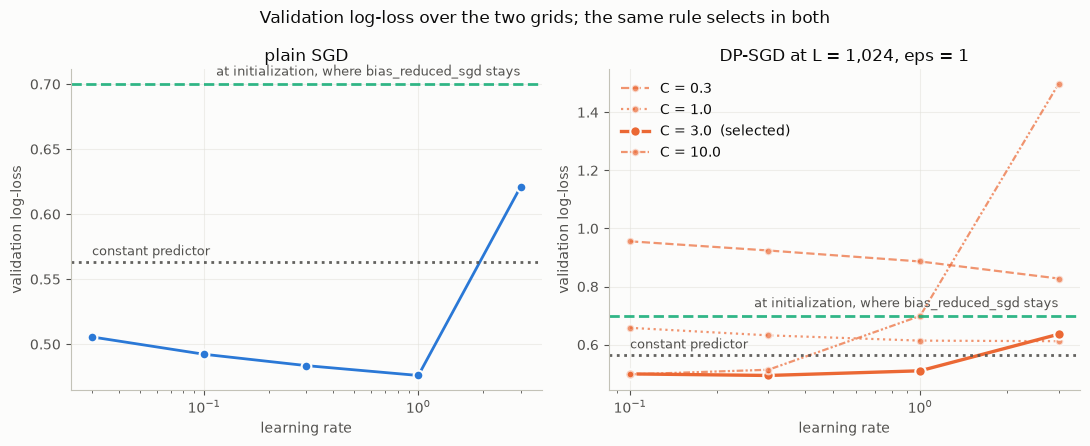

In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

left.plot([row.learning_rate for row in sgd_sweep],
          [row.result.loss for row in sgd_sweep], marker="o",
          color=SERIES["plain SGD"], markeredgecolor=SURFACE,
          markeredgewidth=1.5, label="plain SGD")

# The selected clip is the solid, heavy line; the rest are the dashed
# context it was chosen out of. Emphasis, not four equal series.
dashes = ["--", ":", "-.", (0, (3, 1, 1, 1, 1, 1))]
for index, clip in enumerate(DP_CLIP_GRID):
    rows = [row for row in dp_sweep if row.clip_norm == clip]
    selected = clip == BEST_DP.clip_norm
    right.plot([row.learning_rate for row in rows],
               [row.result.loss for row in rows],
               marker="o", color=SERIES["DP-SGD"],
               linestyle="-" if selected else dashes[index % len(dashes)],
               linewidth=2.4 if selected else 1.6,
               alpha=1.0 if selected else 0.7,
               markersize=7.5 if selected else 5.5,
               markeredgecolor=SURFACE, markeredgewidth=1.5,
               label=f"C = {clip}" + ("  (selected)" if selected else ""))

for axis, title, grid, legend in (
        (left, "plain SGD", SGD_LR_GRID, False),
        (right, f"DP-SGD at L = {BATCH:,}, eps = {TARGET_EPSILON:g}",
         DP_LR_GRID, True)):
    axis.axhline(CONST.loss, color=MUTED, linestyle=":", alpha=0.9)
    axis.annotate("constant predictor", xy=(grid[0], CONST.loss),
                  xytext=(0, 5), textcoords="offset points", color=MUTED,
                  fontsize=9)
    axis.axhline(BEFORE.loss, color=SERIES["bias_reduced_sgd"],
                 linestyle="--", alpha=0.9)
    # At the far end of the axis, so it cannot land on the line above it.
    axis.annotate("at initialization, where bias_reduced_sgd stays",
                  xy=(grid[-1], BEFORE.loss), xytext=(0, 6),
                  textcoords="offset points", color=MUTED, fontsize=9,
                  ha="right")
    axis.set_xscale("log")
    axis.set_xlabel("learning rate")
    axis.set_ylabel("validation log-loss")
    axis.set_title(title)
    # One series needs no legend box: the panel title names it.
    if legend:
        axis.legend(loc="best")
    axis.grid(alpha=0.5)

fig.suptitle("Validation log-loss over the two grids; the same rule selects "
             "in both", color=INK)
fig.tight_layout()
plt.show()

### Reading the two grids

**Both winners are interior, which is what the fourth point on each axis was
for.** Plain SGD's `lr = 1.0` has 0.3 below it and 3.0 above it, and 3.0 is
where the non-private arm falls apart: validation log-loss 0.6210, worse than
a constant predictor, at three times the selected rate. DP-SGD's
`C = 3.0, lr = 0.3` has a clipping norm on either side and a learning rate on
either side, and all four neighbours score worse.

**One caveat on "interior", and it is a real one.** Each grid cell runs at
its own seed — `seed_index` is the configuration's position in the grid — so
a neighbour that scores worse is a configuration *and* a draw scoring worse,
and this cell does not separate the two. Section 9 bounds the second half by
re-running each selected configuration at three seeds: the test log-loss
moves by 0.0012 across seeds for plain SGD and 0.0024 for DP-SGD. Against
that, plain SGD's winner is clear — its nearest neighbour is 0.0076 away and
the next 0.145. DP-SGD's is not: `C = 10.0, lr = 0.1` sits 0.0037 behind at
0.4976, under two seed-ranges, so "C = 3.0 beats C = 10.0" is at the edge of
what one draw each can support. What the grid does establish, and all this
notebook needs from it, is the shape — both axes turn over inside their
range, so the arm below is reported near its best rather than off the end of
a grid.

**The clipping norm is the axis that decides it, and it decides it in the
direction this encoding predicts.** Every per-sample gradient here is
40-sparse with bounded entries, and section 2 measured its ℓ₂ norm at a
median of 2.64 and a 99th percentile of 2.81. So at `C = 3.0` the clip barely
binds: DP-SGD is running very nearly plain SGD's own update, perturbed at
`σ·C / L`, and the sensitivity it pays for is close to the one the data
actually has. Below that the clip rescales most gradients rather than
bounding a few — the `C = 1.0` column runs 0.6119 to 0.6579 and the
`C = 0.3` column 0.8276 to 0.9557, against 0.4939 at the winner. Above it, at
`C = 10.0`, the clip has stopped binding altogether while the noise `σ·C`
keeps growing, and the column turns over: 0.4976 at the smallest learning
rate and 1.4975 at the largest.

That is a fact about the encoding more than about DP-SGD, and it is worth
holding on to, because it is the same property the other private arm was
supposed to exploit. A one-hot row gives a bounded, sparse per-sample
gradient for free, so the clipping norm can be set at the natural bound and
costs almost nothing — which is a large part of why the DP-SGD arm lands
where section 8 finds it.

The ε column is 1.0000 in every row because the multiplier does not depend on
`C`: sixteen configurations, one budget, one noise multiplier, and a utility
comparison rather than a trade-off curve.

The third arm has no panel in that figure because it has no grid. The dashed
green line is where it sits, in both panels; section 6 is where it runs.

## 6. The `bias_reduced_sgd` arm, frozen and re-run at four lengths

Nothing here is selected. The configuration is the bias-reduced-SGD sweep's —
`max_scale = 10`, `C = 1.0`, `radius = C·√40`, `lr = 0.01`, the default
`projection_estimator`, `average_params` as the reported iterate — and what
varies is only the cap. Each point is a separate invocation from the same
initialization: `train` returns no optimizer state, precisely so a run cannot
be resumed and replay its noise stream. All four share a seed, so the coin and
the perturbations are the same sequence in each and the shorter runs are
prefixes of the longer. Four points on one trajectory, not four draws; no gap
between them carries an error bar.

The 3,000-step row is the arm this notebook reports, so it is the same length
as the other two.

**And the point being confirmed is a coin toss, which is worth saying at the
place it is used rather than only in the closing.** The bias-reduced-SGD
sweep's grid ran nine configurations. Their log-losses span 0.043 in total —
0.6970 to 0.7402 — but that spread is two damaged rows at the largest learning
rate, and the other **seven sit within four thousandths of each other** and of
the initialization; the nine PR-AUCs span thirteen thousandths. The log-loss
rule named this configuration, and it has the **worst PR-AUC of its own clip
column** — 0.2538 against 0.2637 at the same `C` and a smaller learning rate.
Under the Criteo convention that the ranking is the headline, a different row
would have been frozen. Nothing in the bias-reduced-SGD sweep could settle
that, because at a multiplier of 250 every gap in its table was inside the
noise of one seed. So the arm below is *one arbitrary member of a flat
region*, and a reader should treat "`bias_reduced_sgd` scores X" as "the nine
indistinguishable configurations score about X".

In [14]:
brs_jobs = [
    (BRS_BLOCK, (lambda cap=cap: fit_brs(max_steps=cap)))
    for cap in BRS_STEP_GRID
]
brs_fits = concurrently(brs_jobs, "bias_reduced_sgd at four lengths")
BRS_FIT = brs_fits[-1]

brs_evals = [on_validation(fit.params) for fit in brs_fits]
print(f"{'steps':>7} {'epsilon':>10}  {COLUMNS} {'prec':>7} {'recall':>7}")
for fit, result in zip(brs_fits, brs_evals):
    precision, recall = rates(result.confusion)
    print(f"{fit.steps:>7,} {fit.epsilon:>10.6f}  {result.loss:9.4f} "
          f"{result.ne:7.4f} {result.ece:7.4f} {result.cal_ratio:10.4f} "
          f"{result.pr_auc:7.4f} {precision:7.4f} {recall:7.4f}")

BRS_LAST = on_validation(BRS_FIT.alt_params)
print()
print(f"{'on the validation split':<28}{COLUMNS}")
print(score_row("constant / PR-AUC floor", CONST))
print(score_row("at initialization", BEFORE))
print(score_row("bias_reduced_sgd, x-bar", brs_evals[-1]))
print(score_row("bias_reduced_sgd, last iterate", BRS_LAST))
print(f"\nrealized epsilon {BRS_FIT.epsilon:.6f} against a guarantee of "
      f"({TARGET_EPSILON:g}, {TARGET_DELTA:.0e}); "
      f"{BRS_FIT.steps:,} steps of the ~{BRS_NATURAL_LENGTH:,.0f} the filter "
      f"would admit")

bias_reduced_sgd at four lengths: 4 runs, 4 at a time, 67s on gpu

  steps    epsilon   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
    200   0.000973     0.7003  1.2440  0.2567     0.4940  0.2614  0.2505  0.9997
    600   0.005316     0.7012  1.2455  0.2570     0.4937  0.2621  0.2505  0.9994
  1,200   0.005568     0.7023  1.2475  0.2574     0.4933  0.2652  0.2505  0.9986
  3,000   0.008521     0.7046  1.2516  0.2583     0.4925  0.2631  0.2506  0.9980

on the validation split      log-loss      NE     ECE  cal-ratio  PR-AUC
constant / PR-AUC floor        0.5630  1.0000  0.0004     0.9983  0.2506
at initialization              0.7001  1.2436  0.2566     0.4941  0.2612
bias_reduced_sgd, x-bar        0.7046  1.2516  0.2583     0.4925  0.2631
bias_reduced_sgd, last iterate   0.7200  1.2789  0.2624     0.4885  0.2596

realized epsilon 0.008521 against a guarantee of (1, 1e-12); 3,000 steps of the ~82,353 the filter would admit


### Reading those four rows

**Nothing moves, and the longer runs move slightly the wrong way.** The four
log-losses go 0.7003, 0.7012, 0.7023, 0.7046 across a fifteenfold range of
run lengths, against 0.7001 at the initialization and 0.5630 for a constant
predictor. The arm is not converging slowly; it is drifting off its starting
point without improving on it. PR-AUC stays between 0.2614 and 0.2652 against
the initialization's 0.2612 — inside the seed spread section 9 measures, so
not a movement either.

Every row's confusion matrix is the degenerate one. At the base-rate
threshold a model whose logits are still near zero puts essentially every
record above the cut: precision is the base rate to four decimals in all four
rows, and recall never falls below 0.998 — 0.9997 at 200 steps, easing to
0.9980 at 3,000 as the iterate drifts. That is what a model which has learned
nothing looks like at this operating point, and it is worth seeing once
before section 8 shows it beside two models that have.

**The realized ε confirms how little was spent, and that is not the problem.**
The longest run charges 0.0085 against a budget of 1, because 3,000 steps is
3.6% of the 82,353 the filter would admit at this `max_scale`. The cap costs
utility and never privacy — and it bought no quieter step either, since the
inner multiplier is fixed by `(ε, δ)` and by nothing else. The
bias-reduced-SGD sweep priced the missing steps directly rather than guessing
at them: one debiased estimate there carried a root-mean-square error 828
times the length of the gradient it was estimating, which the `sqrt(T)`
averaging argument pays off only at about 685,000 steps against the ~94,000
its filter admitted. Running this arm to its own stopping point does not close
that gap, and no larger ε is available, because `train` refuses one.

## 7. The trajectory, all three arms on one axis

Same three arms, same 3,000 steps, read on the same held-out 100,000 rows
between chunks. The two arms that can be resumed are run once and evaluated
at 20 chunk boundaries, threading the parameters, the numpy sampling stream
and a per-chunk JAX key through; the loop itself is never reimplemented. The
optimizer state and the epoch stream restart at each boundary, which is
harmless without momentum, and the privacy analysis is unchanged: still 3,000
Poisson-sampled Gaussian releases at the calibrated σ. The
`bias_reduced_sgd` arm cannot be chunked for the reason section 6 gives, so
its curve is the four prefix runs already executed.

In [15]:
CHUNK_STEPS = STEPS // TRAJECTORY_CHUNKS


class Arm(NamedTuple):
    """What the cells that walk all three arms need to know about one.

    Written once because two of them -- this trajectory and section 9's
    seed repeats -- would otherwise each carry the same switch on the
    arm's name.
    """

    block: int
    """What its largest step allocates, for `pool_size` (section 4)."""
    repeat: Callable[[int], Fit]
    """Train it once at one seed index, at the selected configuration."""
    resume: Callable[..., tuple[Fit, Any]] | None
    """Carry one chunk of a trajectory and hand the sampling stream
    back. `None` for `bias_reduced_sgd`: its `train` returns no optimizer
    state, precisely so a run cannot be resumed and replay its noise."""


def sgd_repeat(seed_index):
    fit, _ = fit_sgd(learning_rate=BEST_SGD.learning_rate,
                     seed_index=seed_index)
    return fit


def sgd_resume(*, steps, chunk, params, rng):
    del chunk  # plain SGD has no noise stream to fold a chunk index into
    return fit_sgd(learning_rate=BEST_SGD.learning_rate, steps=steps,
                   params=params, rng=rng)


def dp_repeat(seed_index):
    fit, _ = fit_dp_sgd(learning_rate=BEST_DP.learning_rate,
                        clip_norm=BEST_DP.clip_norm, seed_index=seed_index)
    return fit


def dp_resume(*, steps, chunk, params, rng):
    return fit_dp_sgd(learning_rate=BEST_DP.learning_rate,
                      clip_norm=BEST_DP.clip_norm, steps=steps, chunk=chunk,
                      params=params, rng=rng)


def brs_repeat(seed_index):
    return fit_brs(seed_index=seed_index)


ARM_RUNNERS = {
    "plain SGD": Arm(block=0, repeat=sgd_repeat, resume=sgd_resume),
    "DP-SGD": Arm(block=DP_BLOCK, repeat=dp_repeat, resume=dp_resume),
    "bias_reduced_sgd": Arm(block=BRS_BLOCK, repeat=brs_repeat, resume=None),
}
RESUMABLE = [arm for arm in ARMS if ARM_RUNNERS[arm].resume is not None]


def chunked(arm):
    """`STEPS` steps in `TRAJECTORY_CHUNKS` chunks, recording between them."""
    resume = ARM_RUNNERS[arm].resume
    params = fresh_params()
    _, rng = streams(0)
    record = [(0, on_validation(params))]
    for chunk in range(TRAJECTORY_CHUNKS):
        fit, rng = resume(steps=CHUNK_STEPS, chunk=chunk, params=params,
                          rng=rng)
        params = fit.params
        record.append(((chunk + 1) * CHUNK_STEPS, on_validation(params)))
    return params, record


FINAL, CURVE = {}, {}
for arm in RESUMABLE:
    t0 = time.time()
    FINAL[arm], CURVE[arm] = chunked(arm)
    last = CURVE[arm][-1][1]
    print(f"{arm:<18} {STEPS:,} steps in {time.time() - t0:5.0f}s   "
          f"validation log-loss {last.loss:.4f}   PR-AUC {last.pr_auc:.4f}   "
          f"ECE {last.ece:.4f}")

brs_lengths = [fit.steps for fit in brs_fits]
brs_points = list(zip(brs_lengths, brs_evals))
start_point = (0, BEFORE)
FINAL["bias_reduced_sgd"] = BRS_FIT.params
CURVE["bias_reduced_sgd"] = [start_point] + brs_points
brs_last = brs_evals[-1]
print(f"{'bias_reduced_sgd':<18} {STEPS:,} steps, "
      f"{len(brs_points)} prefix runs   "
      f"validation log-loss {brs_last.loss:.4f}   "
      f"PR-AUC {brs_last.pr_auc:.4f}   ECE {brs_last.ece:.4f}")

# The last point of each curve is that arm's reported model on the
# selection split, so section 8's F1 cuts read it rather than scoring
# the same parameters a second time.
VALIDATION = {arm: CURVE[arm][-1][1] for arm in ARMS}

plain SGD          3,000 steps in     8s   validation log-loss 0.4753   PR-AUC 0.5316   ECE 0.0080


DP-SGD             3,000 steps in    44s   validation log-loss 0.4937   PR-AUC 0.5028   ECE 0.0324
bias_reduced_sgd   3,000 steps, 4 prefix runs   validation log-loss 0.7046   PR-AUC 0.2631   ECE 0.2583


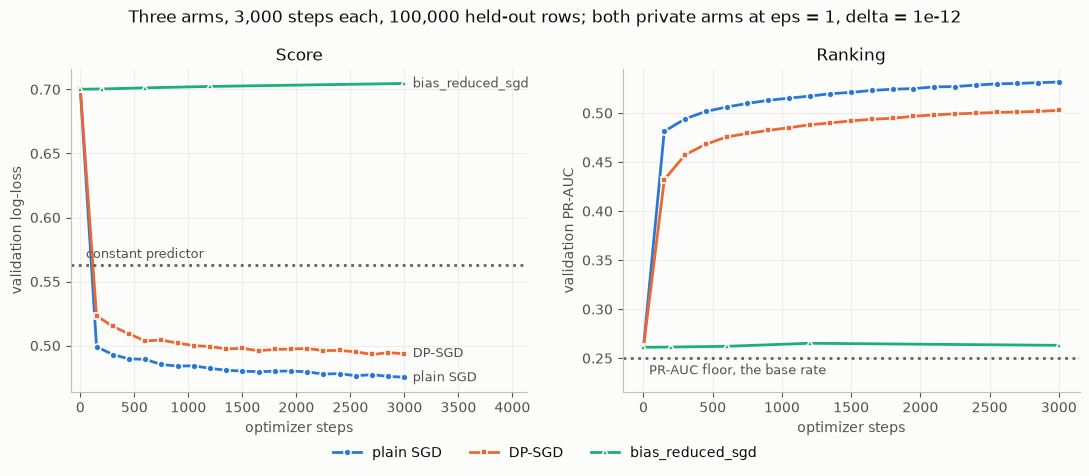

In [16]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

for arm in ARMS:
    steps_axis = [point[0] for point in CURVE[arm]]
    losses = [point[1].loss for point in CURVE[arm]]
    aucs = [point[1].pr_auc for point in CURVE[arm]]
    left.plot(steps_axis, losses, color=SERIES[arm], label=arm,
              marker=MARKERS[arm], markeredgecolor=SURFACE,
              markeredgewidth=1.2, markersize=5)
    right.plot(steps_axis, aucs, color=SERIES[arm], label=arm,
               marker=MARKERS[arm], markeredgecolor=SURFACE,
               markeredgewidth=1.2, markersize=5)
    # The left panel's three endpoints are far enough apart to name in
    # place; the right panel's two upper ones are not, so that one is
    # read off the legend and the table above.
    left.annotate(arm, xy=(steps_axis[-1], losses[-1]), xytext=(6, 0),
                  textcoords="offset points", color=MUTED, fontsize=9,
                  va="center")

left.axhline(CONST.loss, color=MUTED, linestyle=":", alpha=0.9)
left.annotate("constant predictor", xy=(0, CONST.loss), xytext=(4, 5),
              textcoords="offset points", color=MUTED, fontsize=9)
ranked = [point[1].pr_auc for arm in ARMS for point in CURVE[arm]]
right.axhline(VAL_BASE_RATE, color=MUTED, linestyle=":", alpha=0.9)
# Room under the floor line, so its label is not read as a tick label.
right.set_ylim(bottom=min(ranked + [VAL_BASE_RATE]) - 0.035)
right.annotate("PR-AUC floor, the base rate", xy=(0, VAL_BASE_RATE),
               xytext=(4, -12), textcoords="offset points", color=MUTED,
               fontsize=9)

left.set_xlim(-STEPS * 0.03, STEPS * 1.38)   # room for the direct labels
for axis, title, ylabel in (
        (left, "Score", "validation log-loss"),
        (right, "Ranking", "validation PR-AUC")):
    axis.set_xlabel("optimizer steps")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(alpha=0.5)

# One legend for the figure rather than one per panel: the two panels carry
# the same three series, and inside either of them a box lands on a curve.
handles, keys = left.get_legend_handles_labels()
fig.legend(handles, keys, loc="lower center", ncol=len(ARMS),
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f"Three arms, {STEPS:,} steps each, 100,000 held-out rows; both "
             f"private arms at eps = {TARGET_EPSILON:g}, "
             f"delta = {TARGET_DELTA:.0e}", color=INK)
fig.tight_layout()
plt.show()

## 8. The operating point, then the test split

The threshold rule was fixed in section 2 and is the same for all three arms:
flag a record whose predicted probability is at or above the **training base
rate**. It is one number, chosen before any run, and no read of the test
labels enters it.

**Which parameters each arm is reported at**, said once here because two of
the three return only one set: plain SGD and DP-SGD are scored at the
parameters their loops return, and `bias_reduced_sgd` at `average_params` —
`x̄`, the mean of `x⁰ … x^T`, which is the output rule Theorem 5.6's bound is
stated for and the one section 6 reports. Its last iterate is in section 6's
table beside it; no bound covers that one.

Now, and only now, the test split.

In [17]:
TEST = {arm: evaluate_at(FINAL[arm], IDX_TEST, VAL_TEST, Y_TEST)
        for arm in ARMS}

TEST_CONST = constant_predictor(base_rate, Y_TEST, base_rate)

print(f"{'on the test split':<28}{COLUMNS}")
print(score_row("constant at the base rate", TEST_CONST))
for arm in ARMS:
    print(score_row(arm, TEST[arm]))
print("(the bias_reduced_sgd row is `average_params`, x-bar -- the output "
      "rule section 6 reports;")
print(" its last iterate is in section 6's table, and no bound covers it.)")

print(f"\n{'':<28}{'epsilon':>10} {'delta':>10} {'steps':>9} "
      f"{'guarantee':>16}")
print(f"{'plain SGD':<28}{'-':>10} {'-':>10} {STEPS:>9,} "
      f"{'none at all':>16}")
print(f"{'DP-SGD':<28}{DP_EPSILON_BACK:>10.4f} {TARGET_DELTA:>10.0e} "
      f"{STEPS:>9,} {f'({TARGET_EPSILON:g}, {TARGET_DELTA:.0e})':>16}")
print(f"{'bias_reduced_sgd':<28}{BRS_FIT.epsilon:>10.4f} "
      f"{TARGET_DELTA:>10.0e} {BRS_FIT.steps:>9,} "
      f"{f'({TARGET_EPSILON:g}, {TARGET_DELTA:.0e})':>16}")
print("\nthe two private arms hold the same (epsilon, delta); the realized "
      "numbers differ because")
print("DP-SGD's noise was calibrated to spend the budget and the filter's is "
      "not (ADR-0018).")

on the test split            log-loss      NE     ECE  cal-ratio  PR-AUC
constant at the base rate      0.5645  1.0000  0.0000     1.0000  0.2520
plain SGD                      0.4782  0.8471  0.0053     0.9849  0.5281
DP-SGD                         0.4964  0.8793  0.0328     1.1359  0.4998
bias_reduced_sgd               0.7046  1.2481  0.2573     0.4948  0.2642
(the bias_reduced_sgd row is `average_params`, x-bar -- the output rule section 6 reports;
 its last iterate is in section 6's table, and no bound covers it.)

                               epsilon      delta     steps        guarantee
plain SGD                            -          -     3,000      none at all
DP-SGD                          1.0000      1e-12     3,000       (1, 1e-12)
bias_reduced_sgd                0.0085      1e-12     3,000       (1, 1e-12)

the two private arms hold the same (epsilon, delta); the realized numbers differ because
DP-SGD's noise was calibrated to spend the budget and the filter's is not (AD

In [18]:
for arm in ARMS:
    show_confusion(TEST[arm].confusion, f"{arm} on the test split")
    print()

plain SGD on the test split
                 predicted no    predicted click
  actual no           101,357             48,243
  actual click         14,721             35,679
  precision 0.4251   recall 0.7079   (at threshold p >= 0.2510)

DP-SGD on the test split
                 predicted no    predicted click
  actual no           112,222             37,378
  actual click         20,389             30,011
  precision 0.4453   recall 0.5955   (at threshold p >= 0.2510)

bias_reduced_sgd on the test split
                 predicted no    predicted click
  actual no               276            149,324
  actual click             70             50,330
  precision 0.2521   recall 0.9986   (at threshold p >= 0.2510)



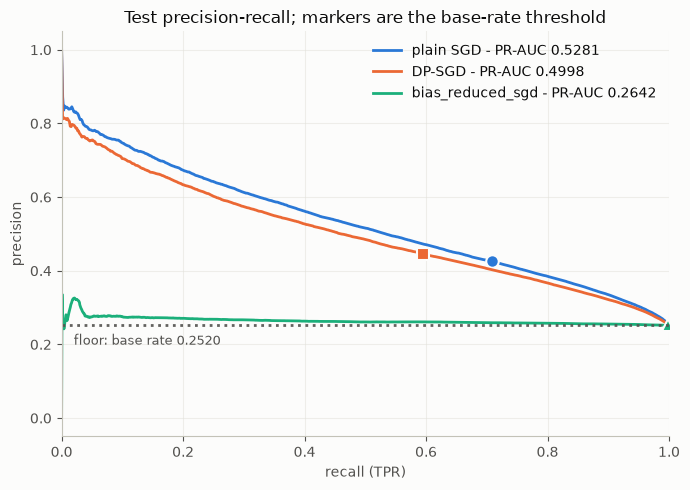

In [19]:
fig, axis = plt.subplots(figsize=(7, 5))

for arm in ARMS:
    curve = pr_curve(TEST[arm].probs, Y_TEST)
    # ~2000 points is plenty for a 200k-row curve and keeps the file small.
    stride = max(1, len(curve.recall) // 2000)
    precision, recall = rates(TEST[arm].confusion)
    label = f"{arm} - PR-AUC {TEST[arm].pr_auc:.4f}"
    axis.plot(curve.recall[::stride], curve.precision[::stride],
              color=SERIES[arm], label=label)
    axis.plot([recall], [precision], marker=MARKERS[arm], color=SERIES[arm],
              linestyle="none", markersize=9, markeredgecolor=SURFACE,
              markeredgewidth=1.5)

axis.axhline(base_rate, color=MUTED, linestyle=":", alpha=0.9)
axis.annotate(f"floor: base rate {base_rate:.4f}", xy=(0.02, base_rate),
              xytext=(0, -14), textcoords="offset points", color=MUTED,
              fontsize=9)
axis.set_xlabel("recall (TPR)")
axis.set_ylabel("precision")
axis.set_xlim(0, 1)
axis.set_title("Test precision-recall; markers are the base-rate threshold")
axis.legend(loc="upper right")
axis.grid(alpha=0.5)
fig.tight_layout()
plt.show()

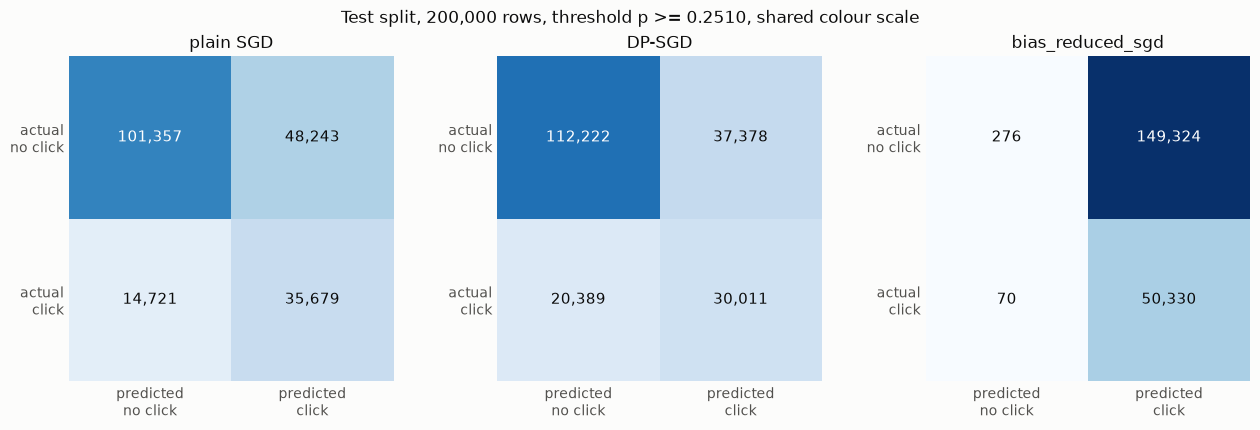

In [20]:
def counts_of(confusion):
    """The 2x2 laid out for `imshow`, read by name rather than position.

    `Confusion` unpacks in scikit-learn's ravelled order, which is the
    transposition its docstring warns about, so the four fields are
    named here and nowhere read off an index.
    """
    return np.array(
        [[confusion.true_negatives, confusion.false_positives],
         [confusion.false_negatives, confusion.true_positives]])


fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
labels = ["no click", "click"]
GRIDS = {arm: counts_of(TEST[arm].confusion) for arm in ARMS}
shared_max = max(int(grid.max()) for grid in GRIDS.values())

for axis, arm in zip(axes, ARMS):
    grid = GRIDS[arm]
    axis.imshow(grid, cmap="Blues", vmin=0, vmax=shared_max)
    for i in range(2):
        for j in range(2):
            shade = "white" if grid[i, j] > shared_max * 0.55 else INK
            axis.text(j, i, f"{grid[i, j]:,}", ha="center", va="center",
                      fontsize=11, color=shade)
    axis.set_xticks([0, 1], [f"predicted\n{name}" for name in labels])
    axis.set_yticks([0, 1], [f"actual\n{name}" for name in labels])
    axis.set_title(arm, color=INK)
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.tick_params(length=0)
    axis.grid(False)

fig.suptitle(f"Test split, {len(Y_TEST):,} rows, threshold p >= "
             f"{THRESHOLD:.4f}, shared colour scale", color=INK)
fig.tight_layout()
plt.show()

### Where the log-loss gap sits, and what a different cut would give

Two footnotes on the table above, neither of which needs another run.

The **decomposition** — `log-loss = calibration − resolution + uncertainty +
residual`, at the same 15 bins — says whether a private arm's extra log-loss
is a miscalibration or a real loss of discriminating power. The
DP-SGD-vs-SGD-baseline comparison found DP-SGD's whole gap in the calibration
term.

The **validation-F1 threshold** is the DP-SGD-vs-SGD-baseline comparison's
operating-point rule, chosen per model on the validation split and applied to
the test split. It is reported here so a reader arriving from the
DP-SGD-vs-SGD-baseline comparison can see that the ranking is a property of
the model while the confusion matrix is a property of the cut.

In [21]:
print(f"{'':<28}{'calibration':>13}{'resolution':>12}{'uncertainty':>13}"
      f"{'residual':>10}{'log-loss':>10}")
DECOMPOSITION = {}
for arm in ARMS:
    parts = log_loss_decomposition(TEST[arm].probs, Y_TEST, n_bins=N_BINS)
    DECOMPOSITION[arm] = parts
    print(f"{arm:<28}{parts.calibration:13.4f}{parts.resolution:12.4f}"
          f"{parts.uncertainty:13.4f}{parts.residual:10.4f}"
          f"{parts.total:10.4f}")

print(f"\n{'':<28}{'threshold':>11}{'val F1':>9}{'TPR':>9}"
      f"{'precision':>11}{'test F1':>9}")
for arm in ARMS:
    point = best_f1_threshold(VALIDATION[arm].probs, Y_VAL)
    at_cut = confusion_at(TEST[arm].probs, Y_TEST, point.threshold)
    precision, recall = rates(at_cut)
    f1 = (2 * precision * recall / (precision + recall)
          if precision + recall else float("nan"))
    print(f"{arm:<28}{point.threshold:11.4f}{point.f1:9.4f}{recall:9.4f}"
          f"{precision:11.4f}{f1:9.4f}")
print("\nPR-AUC does not move with the cut: it is the area under every cut.")

                              calibration  resolution  uncertainty  residual  log-loss
plain SGD                          0.0002      0.0852       0.5645   -0.0013    0.4782
DP-SGD                             0.0051      0.0725       0.5645   -0.0008    0.4964
bias_reduced_sgd                   0.1386      0.0005       0.5645    0.0020    0.7046

                              threshold   val F1      TPR  precision  test F1
plain SGD                        0.2837   0.5347   0.6421     0.4516   0.5302
DP-SGD                           0.2230   0.5153   0.6515     0.4244   0.5140
bias_reduced_sgd                 0.0121   0.4008   1.0000     0.2520   0.4025

PR-AUC does not move with the cut: it is the area under every cut.


## 9. Two questions the tables cannot answer on their own

**Does the ordering survive a change of seed?** Each arm's selected
configuration is re-run at three seeds. The initialization stays
`jax.random.key(0)`; what varies is the sampling stream and, in the two
private arms, the noise. These are monolithic runs rather than the chunked
ones of section 7. Three seeds is a spread, not a confidence interval, and it
is reported as min/max.

**What did δ-parity cost DP-SGD?** One further DP-SGD run at the selected
configuration and δ = 1e-6 — its conventional value, and the DP-SGD sweep's
and the DP-SGD-vs-SGD-baseline comparison's. It is **not budget-matched to
anything else in this notebook** and is reported for one purpose: to put a
number on the price section 3 said parity would charge.

In [22]:
REPEAT_SEED_BASE = 1000


def off_budget_reference():
    """DP-SGD at the conventional delta, matched to nothing else here."""
    fit, _ = fit_dp_sgd(learning_rate=BEST_DP.learning_rate,
                        clip_norm=BEST_DP.clip_norm,
                        noise_multiplier=DP_SIGMA_CONVENTIONAL,
                        seed_index=2000)
    return fit


repeat_jobs = []
for arm in ARMS:
    runner = ARM_RUNNERS[arm]
    for seed_index in SEEDS:
        def one_repeat(train=runner.repeat, i=seed_index):
            return train(REPEAT_SEED_BASE + i)

        repeat_jobs.append((runner.block, one_repeat))
repeat_jobs.append((DP_BLOCK, off_budget_reference))
repeat_fits = concurrently(repeat_jobs, "seed repeats and the delta reference")

REPEATS = {}
for position, arm in enumerate(ARMS):
    window = repeat_fits[position * len(SEEDS):(position + 1) * len(SEEDS)]
    REPEATS[arm] = [evaluate_at(fit.params, IDX_TEST, VAL_TEST, Y_TEST)
                    for fit in window]

for arm in ARMS:
    losses = [result.loss for result in REPEATS[arm]]
    aucs = [result.pr_auc for result in REPEATS[arm]]
    print(f"{arm:<18} test log-loss {np.mean(losses):.4f} "
          f"[{min(losses):.4f}, {max(losses):.4f}]   "
          f"PR-AUC {np.mean(aucs):.4f} [{min(aucs):.4f}, {max(aucs):.4f}]   "
          f"(reported run: {TEST[arm].loss:.4f} / {TEST[arm].pr_auc:.4f})")

OFF_BUDGET = evaluate_at(repeat_fits[-1].params, IDX_TEST, VAL_TEST, Y_TEST)
print()
print(f"{'off-budget reference':<28}{COLUMNS}")
print(score_row("DP-SGD at delta = 1e-6", OFF_BUDGET))
print(score_row(f"DP-SGD at delta = {TARGET_DELTA:.0e} (the reported arm)",
                TEST["DP-SGD"]))
print(f"\nsigma {DP_SIGMA_CONVENTIONAL:.4f} against {DP_SIGMA:.4f}: that "
      f"factor of {DP_SIGMA / DP_SIGMA_CONVENTIONAL:.2f} in noise is what "
      f"delta-parity cost the DP-SGD arm.")

seed repeats and the delta reference: 10 runs, 10 at a time, 190s on gpu



plain SGD          test log-loss 0.4791 [0.4783, 0.4795]   PR-AUC 0.5278 [0.5268, 0.5287]   (reported run: 0.4782 / 0.5281)
DP-SGD             test log-loss 0.4973 [0.4963, 0.4987]   PR-AUC 0.5000 [0.4991, 0.5012]   (reported run: 0.4964 / 0.4998)
bias_reduced_sgd   test log-loss 0.6979 [0.6924, 0.7013]   PR-AUC 0.2688 [0.2635, 0.2765]   (reported run: 0.7046 / 0.2642)

off-budget reference         log-loss      NE     ECE  cal-ratio  PR-AUC
DP-SGD at delta = 1e-6         0.4969  0.8801  0.0387     1.1811  0.5016
DP-SGD at delta = 1e-12 (the reported arm)   0.4964  0.8793  0.0328     1.1359  0.4998

sigma 1.0091 against 1.4243: that factor of 1.41 in noise is what delta-parity cost the DP-SGD arm.


## What this shows, and what it does not

Three arms on the same 700,000 one-hot Criteo rows, the same logistic
regression, the same per-sample loss object, the same initialization and the
same 3,000 optimizer steps, each at the configuration the same
validation-log-loss rule selected, scored on the 200,000 test rows every
other Criteo notebook scores on. Both private arms carry **(ε = 1,
δ = 1e-12)** by the same accountant setting. Thirty-seven training runs, in
fourteen minutes on one RTX 6000 Ada.

**At the budget the sparse method's own analysis admits, DP-SGD costs a
little and `bias_reduced_sgd` costs everything.** Test PR-AUC is **0.5281**
for the non-private baseline, **0.4998** for DP-SGD and **0.2642** for
`bias_reduced_sgd` at `average_params` — x̄, the output rule Theorem 5.6's
bound is stated for and the one every table above reports it at — against a
base-rate floor of 0.2520. Test log-loss is 0.4782, 0.4964 and 0.7046
against a constant predictor's 0.5645. Privacy at
ε = 1 costs the DP-SGD arm 0.0283 of PR-AUC and 0.0182 of log-loss; the third
arm gives up all of it.

**And its 0.2642 is not a small amount of ranking — it is its starting
point.** The floor is the wrong reference here: a freshly initialized model
already ranks at 0.2612 on the validation split, where the arm scores 0.2631.
Nothing was learned and nothing was unlearned.

The log-loss decomposition says the same thing without a threshold in it. The
baseline's **resolution** — the discriminating power in a score, whatever its
calibration — is 0.0852. DP-SGD keeps 0.0725 of that, 85%.
`bias_reduced_sgd` keeps **0.0005**, and its extra log-loss sits almost
entirely in the calibration term: 0.1386, against 0.0051 for DP-SGD and
0.0002 for the baseline.

At the base-rate threshold the picture is two classifiers and a
non-classifier. The baseline catches 35,679 of the 50,400 test clicks at
48,243 false alarms; DP-SGD catches 30,011 at 37,378; `bias_reduced_sgd`
flags 199,654 of the 200,000 records — 50,330 clicks at 149,324 false alarms
— which is the everything-is-a-click answer a model with logits near zero
gives. At each model's own validation-F1 cut the test F1s are 0.5302, 0.5140
and 0.4025, and the PR-AUCs are unchanged, because a cut moves the matrix and
never the ranking.

**Three seeds separate the two arms that work, which the
DP-SGD-vs-SGD-baseline comparison's did not.** On the dense encoding at ε = 3
that notebook found the private and non-private PR-AUCs indistinguishable and
the gap changing sign across seeds. Here the three-seed ranges are disjoint —
0.5268–0.5287 for the baseline against 0.4991–0.5012 for DP-SGD — so the 0.028
is a real cost rather than noise. `bias_reduced_sgd` spans 0.2635–0.2765, a
range 0.013 wide against the 0.017 that separates its own middle from the
floor: three readings of a model that has not moved.

**On the budget parity, and what it turned out to cost.** Section 3 chose to
hold *both* private arms at δ = 1e-12 — the `δ < 1 / n²` precondition
`bias_reduced_sgd`'s step-count bound needs — rather than let DP-SGD run at
the 1e-6 its own literature uses, on the grounds that a smaller δ is a
strictly stronger guarantee and parity should never be bought by weakening
the arm that does not need it. The stated price was 41% more noise:
σ = 1.4243 against 1.0091. Section 9 measured what that bought back, and the
answer is nothing anyone would notice — DP-SGD at δ = 1e-6 scores test
log-loss 0.4969 and PR-AUC 0.5016, against 0.4964 and 0.4998 at parity, both
inside the three-seed spread of the parity arm itself. **The decision was
free.** It would not have been at a smaller ε or a smaller lot, and it is
reported because the reader has to be able to see that rather than take it.

**What the sparsity assumption did and did not buy.** It held exactly:
`load_criteo_one_hot` makes every per-sample gradient 40-sparse by
construction, which is assumption (A.7) as a fact rather than a hope, and it
is the condition the whole method exists for. It bought the DP-SGD arm a
tight, nearly free clipping norm, which section 5 reads off the grid. It did
not buy `bias_reduced_sgd` anything here, because the binding constraint is
elsewhere: at ε = 1 with δ = 1e-12 every inner release runs at a multiplier
of 250, and the number of steps needed for that to average out is an order of
magnitude past what the privacy filter admits. Sparse gradients are necessary
for the method's rate and they are not sufficient at this budget.

Not shown, and not claimed:

- **This is not a verdict on the method.** It is a verdict on this method at
  ε ≤ 1 on this problem — 551,947 coordinates, a 40-sparse gradient, and a
  filter that stops after about 82,000 steps. The paper's regime wants `s`
  small against `d`, which holds here by construction, *and* enough steps for
  the estimate to average, which does not.
- **The frozen operating point is one of nine indistinguishable rows.** The
  bias-reduced-SGD sweep's log-loss rule named it, and that row was the worst
  ranker of its own clip column; a PR-AUC rule would have frozen a different
  one. This notebook inherits the coin toss rather than settling it. What it
  can say is that the spread of those nine — thirteen thousandths of PR-AUC in
  that sweep — is nowhere near the 0.24 separating this arm from DP-SGD, so
  the comparison does not turn on which of them was frozen.
- **`max_steps` capped every run in the third arm at 3,000**, 3.6% of what the
  filter would admit. That costs utility and never privacy, and the
  bias-reduced-SGD sweep's section 8 is the reason the uncapped run is not
  expected to come out differently — an argument from a measured error ratio,
  not a measurement of the long run.
- **The two ε columns are the same number and not the same argument.**
  DP-SGD's sensitivity is *enforced* by the per-sample clip;
  `bias_reduced_sgd`'s guarantee rests on Lemma 5.3's amplification, a
  statement about a fixed-size draw *without* replacement, which is not the
  Poisson statement `accounting.sampling` wraps and which
  `accounting.bias_reduced_sgd`'s module docstring records as one of four
  things it cannot check.
- **The search is unaccounted.** The twenty-one runs in the two grids each
  read a validation loss; the reported ε covers the selected run only.
- **The preprocessing statistics are unaccounted** (ADR-0008). The one-hot
  vocabulary and the integer-column medians are fitted on the training split,
  and the validation rows were inside the split they were fitted on.
- **Three seeds is a spread, not a confidence interval.**
- **One budget, one dataset, one model**: logistic regression on Criteo at
  ε = 1, on the sparse encoding, at a lot of 1,024.
- **The two accountings are different machines.** DP-SGD's ε is RDP's
  (ADR-0011) and PLD would report a smaller one for the same run;
  `bias_reduced_sgd`'s is a filter's (ADR-0018), advanced composition over an
  adaptively chosen schedule. A Rényi filter is ticketed as #35 and would buy
  the third arm more steps at the same budget; the bias-reduced-SGD sweep says
  how many more would be needed.
- **This notebook trains on 700,000 rows and the bias-reduced-SGD sweep on
  800,000**, because a comparison holds out a validation split and a sweep did
  not. The third arm's figures here are near the sweep's rather than equal to
  them.
- **The operating point is a choice.** Every confusion matrix above cuts at
  the training base rate; the F1 table in section 8 is the same three models
  at a different cut.